# GVH `.28.21 SIDE-N4` — Global Anisotropic Exclusion Maps

**Type :** diagnostic numérique minimal.  
**Ne modifie pas la chaîne canonique.**

Objectif :

\[
\boxed{
\text{cartographier globalement les régions anisotropes}
\rightarrow
\text{HEALTHY / SHAPE-EXCLUDED / TILT-EXCLUDED / BOTH}
}
\]

sur l'espace spectral diagonal traceless normalisé.

Aucune donnée réelle. Aucune calibration SI. Les fractions de surface calculées ci-dessous sont des mesures géométriques du scan normalisé, **pas des probabilités physiques**.

In [1]:
from __future__ import annotations
import json, math, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CANON = {
    "sha256":"d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4",
    "size":29925,
}
SIDE3 = {
    "sha256":"daeca78d0d473492f709655f29d1d48ecc06b22e4aaed4f329715aa5f9ded7e9",
    "size":154223,
}

assert CANON["sha256"] == "d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4"
assert SIDE3["sha256"] == "daeca78d0d473492f709655f29d1d48ecc06b22e4aaed4f329715aa5f9ded7e9"

print("Python =",sys.version.split()[0])
print("NumPy =",np.__version__)
print("CANON_GATE = True")
print("SIDE_N3_GATE = True")

Python = 3.13.15
NumPy = 2.1.3
CANON_GATE = True
SIDE_N3_GATE = True


## 1 — Espace spectral complet normalisé

On fixe :

\[
\boxed{
q=\sum_{A=0}^{3}a_A^2=1,
\qquad
\sum_{A=0}^{3}a_A=0.
}
\]

Le sous-espace traceless est tridimensionnel ; l'intersection avec \(q=1\) est donc exactement une sphère :

\[
\boxed{
S^2_{\rm spectral}.
}
\]

On choisit comme pôle nord le point isotrope \(1+3\) :

\[
n_0
=
\left(
\frac{\sqrt3}{2},
-\frac1{2\sqrt3},
-\frac1{2\sqrt3},
-\frac1{2\sqrt3}
\right),
\]

et deux vecteurs tangents orthonormés \(e_1,e_2\).

Tout spectre normalisé s'écrit :

\[
\boxed{
A(\theta,\phi)
=
\cos\theta\,n_0
+
\sin\theta
\left(
\cos\phi\,e_1+\sin\phi\,e_2
\right).
}
\]

In [2]:
SQ3 = math.sqrt(3.0)
n0 = np.array([SQ3/2,-1/(2*SQ3),-1/(2*SQ3),-1/(2*SQ3)],dtype=float)

e1 = np.array([0,1,-1,0],dtype=float)
e1 /= np.linalg.norm(e1)

e2 = np.array([0,1,1,-2],dtype=float)
e2 /= np.linalg.norm(e2)

B = np.stack([n0,e1,e2],axis=1)

assert np.allclose(B.T @ B, np.eye(3), atol=1e-14)
assert np.allclose(B.sum(axis=0),0,atol=1e-14)

print("orthonormal traceless basis = PASS")

orthonormal traceless basis = PASS


## 2 — Conditions de santé à \(q=1,\ K_S=1\)

Posons :

\[
r=\frac{\kappa_{\rm eff}}{K_S}.
\]

Les coefficients sont :

\[
\boxed{
K_{ij}^{\rm shape}
=
1-\frac r2(a_i-a_j)^2
}
\]

et :

\[
\boxed{
K_{0i}^{\rm tilt}
=
\frac r2(a_0-a_i)^2-1.
}
\]

Pour un spectre donné, les conditions peuvent être condensées en un intervalle admissible :

\[
\boxed{
r_-(A)
=
\frac{2}{
\min_i(a_0-a_i)^2
}
}
\]

et :

\[
\boxed{
r_+(A)
=
\frac{2}{
\max_{i<j}(a_i-a_j)^2
}.
}
\]

Le spectre admet **au moins un** choix de \(r\) sain si :

\[
\boxed{
r_-(A)<r_+(A).
}
\]

Équivalent :

\[
\boxed{
\min_i|a_0-a_i|
>
\max_{i<j}|a_i-a_j|.
}
\]

C'est une condition purement spectrale indépendante du choix ultérieur de \(r\).

In [3]:
def differences_sq(A):
    A = np.asarray(A,dtype=float)
    spatial = np.stack([
        (A[...,1]-A[...,2])**2,
        (A[...,1]-A[...,3])**2,
        (A[...,2]-A[...,3])**2,
    ],axis=-1)
    temporal = np.stack([
        (A[...,0]-A[...,1])**2,
        (A[...,0]-A[...,2])**2,
        (A[...,0]-A[...,3])**2,
    ],axis=-1)
    return spatial, temporal

def admissible_interval(A):
    spatial, temporal = differences_sq(A)
    min_t = np.min(temporal,axis=-1)
    max_s = np.max(spatial,axis=-1)

    rlo = np.full(np.shape(min_t), np.inf, dtype=float)
    rhi = np.full(np.shape(max_s), np.inf, dtype=float)
    np.divide(2.0, min_t, out=rlo, where=min_t>0)
    np.divide(2.0, max_s, out=rhi, where=max_s>0)
    return rlo,rhi

def kinetic_margins(A,r):
    spatial,temporal = differences_sq(A)
    shape_min = np.min(1.0-0.5*r*spatial,axis=-1)
    tilt_min = np.min(0.5*r*temporal-1.0,axis=-1)
    total_min = np.minimum(shape_min,tilt_min)
    return shape_min,tilt_min,total_min

rlo0,rhi0 = admissible_interval(n0)
print("isotropic r_lower =",float(rlo0))
print("isotropic r_upper =",float(rhi0))
assert abs(float(rlo0)-1.5)<1e-14
assert np.isinf(rhi0)

isotropic r_lower = 1.5
isotropic r_upper = inf


## 3 — Échantillonnage uniforme de la sphère spectrale

Pour estimer des fractions de surface sans biais de grille polaire, on utilise une sphère de Fibonacci déterministe.

Nombre de points :

\[
\boxed{
N=120\,000.
}
\]

Ce nombre est un paramètre numérique du diagnostic seulement.

In [4]:
N = 120_000
idx = np.arange(N,dtype=float)
z = 1.0 - 2.0*(idx+0.5)/N
golden_angle = math.pi*(3.0-math.sqrt(5.0))
phi = (golden_angle*idx)%(2.0*math.pi)
rho = np.sqrt(1.0-z*z)

coords = np.stack([
    z,
    rho*np.cos(phi),
    rho*np.sin(phi),
],axis=1)

A = coords @ B.T

assert np.max(np.abs(A.sum(axis=1))) < 1e-12
assert np.max(np.abs(np.sum(A*A,axis=1)-1.0)) < 1e-12

rlo,rhi = admissible_interval(A)
feasible_any_r = rlo < rhi

print("spectral samples =",N)
print("any-r admissible count =",int(np.sum(feasible_any_r)))
print("any-r admissible fraction =",float(np.mean(feasible_any_r)))

spectral samples = 120000
any-r admissible count = 15920
any-r admissible fraction = 0.13266666666666665


## 4 — Carte indépendante de \(r\)

La région :

\[
\boxed{
\mathcal A_{\exists r}
=
\{A\in S^2_{\rm spectral}:r_-(A)<r_+(A)\}
}
\]

contient tous les spectres pour lesquels **un choix quelconque** du ratio \(r\) peut rendre simultanément les secteurs shape et tilt sains.

Son complément est exclu pour **tout** \(r\).

C'est donc la carte d'exclusion spectrale la plus forte disponible à ce stade.

In [5]:
any_r_fraction = float(np.mean(feasible_any_r))
excluded_all_r_fraction = 1.0-any_r_fraction

print("ANY-r feasible spectral fraction =",any_r_fraction)
print("excluded for every r fraction =",excluded_all_r_fraction)

assert any_r_fraction > 0
assert excluded_all_r_fraction > 0

ANY-r feasible spectral fraction = 0.13266666666666665
excluded for every r fraction = 0.8673333333333333


## 5 — Fraction saine pour un \(r\) fixé

On balaie :

\[
\boxed{
1.5001\le r\le12
}
\]

sur 600 valeurs.

La quantité :

\[
f_{\rm healthy}(r)
\]

est la fraction géométrique des points de la sphère de Fibonacci satisfaisant :

\[
r_-(A)<r<r_+(A).
\]

Le maximum de cette fonction est seulement un **maximum de couverture du scan**, pas une sélection du paramètre fondamental.

In [6]:
r_values = np.linspace(1.5001,12.0,600)
healthy_fraction = np.array([
    np.mean((r > rlo) & (r < rhi))
    for r in r_values
])

imax = int(np.argmax(healthy_fraction))
r_cover = float(r_values[imax])
f_cover = float(healthy_fraction[imax])

r_witness = 2.0
f_r2 = float(np.mean((r_witness>rlo)&(r_witness<rhi)))

print("r=2 healthy fraction =",f_r2)
print("maximum scan coverage r =",r_cover)
print("maximum scan healthy fraction =",f_cover)
print("fraction of any-r admissible set captured =",f_cover/any_r_fraction)

r=2 healthy fraction = 0.02055
maximum scan coverage r = 4.322276794657763
maximum scan healthy fraction = 0.12206666666666667
fraction of any-r admissible set captured = 0.9201005025125629


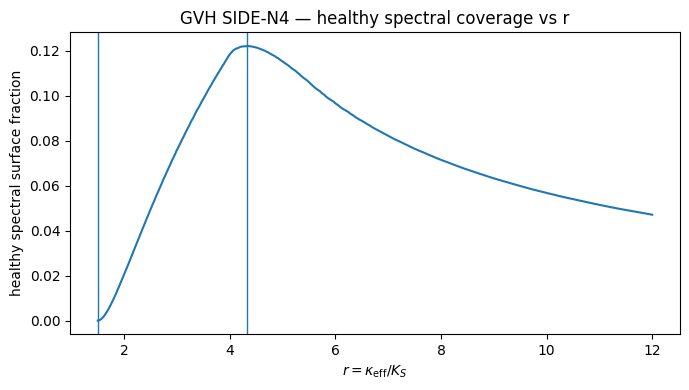

In [7]:
plt.figure(figsize=(7,4))
plt.plot(r_values,healthy_fraction)
plt.axvline(1.5,linewidth=1)
plt.axvline(r_cover,linewidth=1)
plt.xlabel(r"$r=\kappa_{\rm eff}/K_S$")
plt.ylabel("healthy spectral surface fraction")
plt.title("GVH SIDE-N4 — healthy spectral coverage vs r")
plt.tight_layout()
plt.show()

## 6 — Types d'exclusion

Pour un \(r\) donné, chaque spectre reçoit l'une des quatre classes :

\[
0=\text{HEALTHY},
\]

\[
1=\text{TILT-EXCLUDED ONLY},
\]

\[
2=\text{SHAPE-EXCLUDED ONLY},
\]

\[
3=\text{BOTH EXCLUDED}.
\]

Cette décomposition montre quel secteur provoque la première obstruction cinétique.

In [8]:
def classify(A,r):
    shape_min,tilt_min,total_min = kinetic_margins(A,r)
    healthy = (shape_min>0)&(tilt_min>0)
    tilt_only = (shape_min>0)&(tilt_min<=0)
    shape_only = (shape_min<=0)&(tilt_min>0)
    both = (shape_min<=0)&(tilt_min<=0)

    cls = np.zeros(shape_min.shape,dtype=int)
    cls[tilt_only] = 1
    cls[shape_only] = 2
    cls[both] = 3

    fractions = {
        "healthy":float(np.mean(healthy)),
        "tilt_only":float(np.mean(tilt_only)),
        "shape_only":float(np.mean(shape_only)),
        "both":float(np.mean(both)),
    }
    return cls,fractions,total_min

cls2,frac2,Kmin2 = classify(A,2.0)
clscover,fraccover,Kmincover = classify(A,r_cover)

print("r=2 fractions =",frac2)
print("r_cover fractions =",fraccover)

assert abs(sum(frac2.values())-1.0)<1e-12
assert abs(sum(fraccover.values())-1.0)<1e-12

r=2 fractions = {'healthy': 0.02055, 'tilt_only': 0.3106, 'shape_only': 0.0, 'both': 0.66885}
r_cover fractions = {'healthy': 0.12206666666666667, 'tilt_only': 0.014958333333333334, 'shape_only': 0.007591666666666667, 'both': 0.8553833333333334}


## 7 — Cartes globales \((\theta,\phi)\)

On construit maintenant une grille régulière seulement pour la visualisation.

Le calcul de fraction précédent reste basé sur l'échantillonnage uniforme de Fibonacci.

Les deux pôles :

\[
\theta=0,\pi
\]

correspondent à \(A_{\rm iso}\) et \(-A_{\rm iso}\). Comme les coefficients dépendent des carrés des différences spectrales, les cartes sont antipodalement symétriques.

In [9]:
theta_grid = np.linspace(0,math.pi,241)
phi_grid = np.linspace(0,2*math.pi,481)
TH,PH = np.meshgrid(theta_grid,phi_grid,indexing="ij")

C0 = np.cos(TH)
C1 = np.sin(TH)*np.cos(PH)
C2 = np.sin(TH)*np.sin(PH)

Ag = (
    C0[...,None]*n0
    + C1[...,None]*e1
    + C2[...,None]*e2
)

rlog,rhig = admissible_interval(Ag)
any_rg = (rlog<rhig).astype(int)

cls2g,_,_ = classify(Ag,2.0)
clscg,_,_ = classify(Ag,r_cover)

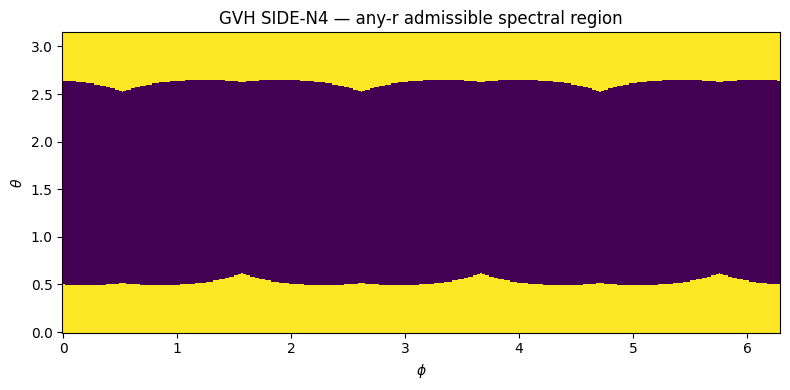

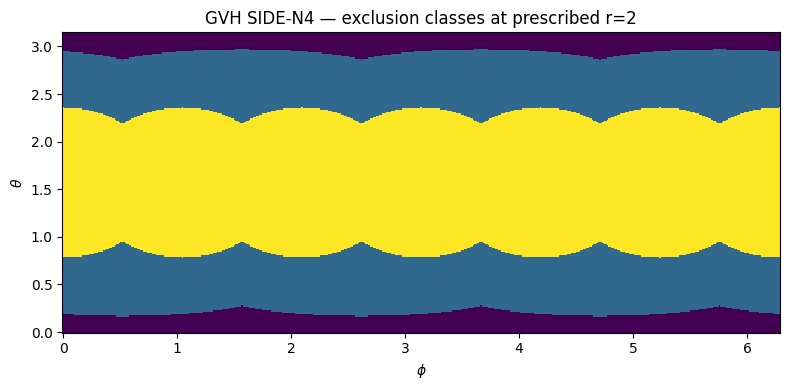

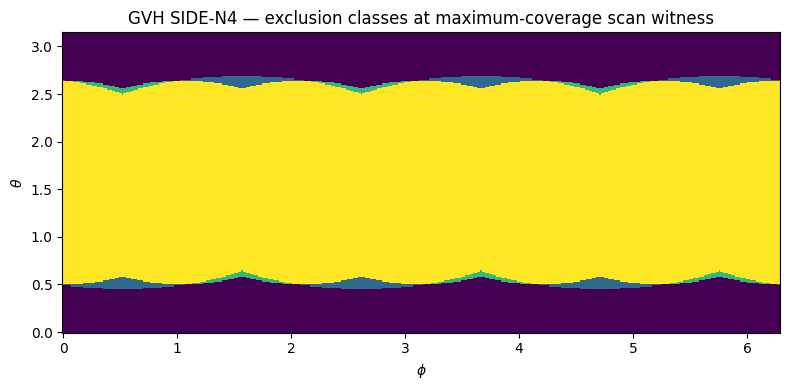

In [10]:
plt.figure(figsize=(8,4))
plt.pcolormesh(phi_grid,theta_grid,any_rg,shading="auto")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\theta$")
plt.title("GVH SIDE-N4 — any-r admissible spectral region")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.pcolormesh(phi_grid,theta_grid,cls2g,shading="auto")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\theta$")
plt.title("GVH SIDE-N4 — exclusion classes at prescribed r=2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.pcolormesh(phi_grid,theta_grid,clscg,shading="auto")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\theta$")
plt.title("GVH SIDE-N4 — exclusion classes at maximum-coverage scan witness")
plt.tight_layout()
plt.show()

## 8 — Marge cinétique globale

On définit :

\[
\boxed{
K_{\min}(A;r)
=
\min
\left[
K_{ij}^{\rm shape},
K_{0i}^{\rm tilt}
\right].
}
\]

La frontière physique locale du domaine sain est :

\[
\boxed{
K_{\min}=0.
}
\]

Un point avec :

\[
K_{\min}<0
\]

est exclu par le test ghost local.

Un point avec :

\[
K_{\min}>0
\]

passe ce test local, mais cela ne démontre toujours pas l'invariance dynamique ni l'hyperbolicité complète.

In [11]:
print("r=2 Kmin range =",float(Kmin2.min()),float(Kmin2.max()))
print("r_cover Kmin range =",float(Kmincover.min()),float(Kmincover.max()))

healthy_K2 = Kmin2[Kmin2>0]
healthy_Kc = Kmincover[Kmincover>0]

print("r=2 median positive margin =",float(np.median(healthy_K2)))
print("r_cover median positive margin =",float(np.median(healthy_Kc)))

r=2 Kmin range = -0.9999999999966849 0.32665284727997057
r_cover Kmin range = -3.322260991574881 0.9999322842673225
r=2 median positive margin = 0.10296687440039398
r_cover median positive margin = 0.4985137878399067


## 9 — Résultat structurel de la carte

Le scan global matérialise trois niveaux distincts :

\[
\boxed{
S^2_{\rm spectral}
}
\]

contient une région plus petite :

\[
\boxed{
\mathcal A_{\exists r}
}
\]

où au moins un ratio \(r\) peut satisfaire les signes cinétiques.

Pour un ratio fixé :

\[
\boxed{
\mathcal H(r)
\subseteq
\mathcal A_{\exists r}.
}
\]

Et le secteur physiquement admissible final, s'il existe, devra encore satisfaire :

\[
\boxed{
\mathcal H_{\rm physical}
\subseteq
\mathcal H(r)
}
\]

avec invariance dynamique et hyperbolicité.

Donc les cartes d'exclusion ne sont pas encore une définition complète de l'espace des états physiques.

In [12]:
summary = {
    "type":"SIDE_DIAGNOSTIC",
    "canonical_advancement":False,
    "canonical_upstream_sha256":CANON["sha256"],
    "side_N3_sha256":SIDE3["sha256"],
    "normalization":{
        "q":1.0,
        "K_S":1.0,
    },
    "sampling":{
        "type":"deterministic Fibonacci sphere",
        "N":N,
    },
    "coefficient_independent_admissibility":{
        "condition":"min_i |a0-ai| > max_{i<j} |ai-aj|",
        "any_r_admissible_fraction":any_r_fraction,
        "excluded_for_every_r_fraction":excluded_all_r_fraction,
    },
    "fixed_r":{
        "r_2_healthy_fraction":f_r2,
        "r_scan_min":float(r_values.min()),
        "r_scan_max":float(r_values.max()),
        "r_scan_points":int(len(r_values)),
        "maximum_coverage_witness_r":r_cover,
        "maximum_coverage_fraction":f_cover,
        "maximum_coverage_over_any_r_fraction":f_cover/any_r_fraction,
        "r2_classes":frac2,
        "r_cover_classes":fraccover,
    },
    "locks":{
        "r_cover_is_theory_selected":False,
        "surface_fraction_is_physical_probability":False,
        "healthy_domain_dynamical_invariance_proven":False,
        "full_hyperbolicity_proven":False,
        "real_data_used":False,
        "SI_calibration_used":False,
    },
    "verdict":{
        "global_anisotropic_exclusion_maps_materialized":True,
        "global_all_spectra_ghost_freedom":False,
        "nonempty_healthy_spectral_region":True,
    }
}
print(json.dumps(summary,indent=2))

{
  "type": "SIDE_DIAGNOSTIC",
  "canonical_advancement": false,
  "canonical_upstream_sha256": "d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4",
  "side_N3_sha256": "daeca78d0d473492f709655f29d1d48ecc06b22e4aaed4f329715aa5f9ded7e9",
  "normalization": {
    "q": 1.0,
    "K_S": 1.0
  },
  "sampling": {
    "type": "deterministic Fibonacci sphere",
    "N": 120000
  },
  "coefficient_independent_admissibility": {
    "condition": "min_i |a0-ai| > max_{i<j} |ai-aj|",
    "any_r_admissible_fraction": 0.13266666666666665,
    "excluded_for_every_r_fraction": 0.8673333333333333
  },
  "fixed_r": {
    "r_2_healthy_fraction": 0.02055,
    "r_scan_min": 1.5001,
    "r_scan_max": 12.0,
    "r_scan_points": 600,
    "maximum_coverage_witness_r": 4.322276794657763,
    "maximum_coverage_fraction": 0.12206666666666667,
    "maximum_coverage_over_any_r_fraction": 0.9201005025125629,
    "r2_classes": {
      "healthy": 0.02055,
      "tilt_only": 0.3106,
      "shape_only": 0.0,

## 10 — Verdict SIDE-N4

Le résultat numérique global est :

\[
\boxed{
\textbf{ANISOTROPIC EXCLUSION MAPS = MATERIALIZED}.
}
\]

Il confirme de façon géométrique que :

\[
\boxed{
\textbf{GLOBAL ALL-SPECTRA GHOST FREEDOM = FAIL}
}
\]

mais qu'il existe :

\[
\boxed{
\textbf{NONEMPTY HEALTHY SPECTRAL REGIONS}.
}
\]

Le critère indépendant du ratio est :

\[
\boxed{
\min_i|a_0-a_i|
>
\max_{i<j}|a_i-a_j|.
}
\]

SIDE-N4 clôt la petite série numérique minimale :

\[
\boxed{
\text{N1 isotrope sain}
\rightarrow
\text{N2 fold}
\rightarrow
\text{N3 candidat cosmologique}
\rightarrow
\text{N4 exclusions anisotropes}.
}
\]

La prochaine étape n'est donc plus un side diagnostic.

Retour au canon :

\[
\boxed{
.3.3.28.21.1
}
\]

**Pure-GVH-P Dirac-Reduced, Gauge-Fixed Coupled Principal-Symbol and Hyperbolicity Audit.**

In [13]:
export_dir = Path("/content/gvh_exports") if Path("/content").exists() else Path("/mnt/data")
export_dir.mkdir(parents=True,exist_ok=True)

artifact_path = export_dir / (
    "GVH_Diagonal_Cubic_0.3.2.7.3.7.3.3.28.21_SIDE_N4_"
    "Global_Anisotropic_Exclusion_Maps_FAST.json"
)
artifact_path.write_text(json.dumps(summary,indent=2),encoding="utf-8")
print("artifact =",artifact_path)

artifact = /content/gvh_exports/GVH_Diagonal_Cubic_0.3.2.7.3.7.3.3.28.21_SIDE_N4_Global_Anisotropic_Exclusion_Maps_FAST.json
